# Stage 5 - Transpilation

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os
import json
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap
from qiskit.circuit import Parameter

def load_json_safely(path, fallback_fn):
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"{path} not found -- using fallback computation.")
        return fallback_fn()

# --- Stage 2/3: fixed asset-encoding parameters ---
enc = load_json_safely("results/quantum_encoding_params.json", lambda: None)
if enc is None:
    from scipy.stats import norm
    p0, rho, z_max = 0.25, 0.027, 3.0
    z_fit = np.linspace(-z_max, z_max, 400)
    pd_z = norm.cdf((norm.ppf(p0) - np.sqrt(rho) * z_fit) / np.sqrt(1 - rho))
    theta_fit = np.arcsin(np.sqrt(pd_z))
    alpha, beta = np.polyfit(z_fit, theta_fit, 1)
    enc = {"register_adapted": {}}
    for n in (2, 3):
        n_bins = 2 ** n
        slope = (2 * z_max) / (n_bins - 1)
        enc["register_adapted"][f"{n}_qubit"] = {
            "alpha_tilde": alpha * slope, "beta_tilde": beta - alpha * z_max
        }

# --- Stage 4: trained ansatz angles ---
trained = load_json_safely("results/trained_parameters.json", lambda: None)
if trained is None:
    raise RuntimeError("Run 04_classical_training.ipynb first to produce results/trained_parameters.json")

print("Loaded encoding parameters and trained angles.")
for n in (2, 3):
    print(f"  {n}-qubit: theta* = {trained[f'{n}_qubit']['theta']}, "
          f"alpha_tilde = {enc['register_adapted'][f'{n}_qubit']['alpha_tilde']:.4f}, "
          f"beta_tilde = {enc['register_adapted'][f'{n}_qubit']['beta_tilde']:.4f}")

Loaded encoding parameters and trained angles.
  2-qubit: theta* = [1.5707221568062237, 3.4095575857081593], alpha_tilde = -0.1210, beta_tilde = 0.7055
  3-qubit: theta* = [1.5706602940738232, 0.9606948163165919, 2.286534514795309], alpha_tilde = -0.0518, beta_tilde = 0.7055


In [3]:
def build_bound_circuit(n_z_qubits, theta_values, alpha_tilde, beta_tilde):
    """The full GCI circuit (Stage 3), with the ansatz angles already bound to
    Stage 4's trained numeric values -- no symbolic Parameters remain.
    """
    n_total = n_z_qubits + 1
    asset_qubit = n_z_qubits
    qc = QuantumCircuit(n_total, n_total, name=f"GCI_{n_z_qubits}q_trained")

    for i in range(n_z_qubits):
        qc.ry(theta_values[i], i)
    for i in range(1, n_z_qubits):
        qc.cx(0, i)

    qc.barrier()
    qc.ry(2 * beta_tilde, asset_qubit)
    for k in range(n_z_qubits):
        qc.cry(2 * alpha_tilde * (2 ** k), k, asset_qubit)

    qc.measure(range(n_total), range(n_total))
    return qc

circuits = {}
for n in (2, 3):
    theta = trained[f"{n}_qubit"]["theta"]
    a_tilde = enc["register_adapted"][f"{n}_qubit"]["alpha_tilde"]
    b_tilde = enc["register_adapted"][f"{n}_qubit"]["beta_tilde"]
    circuits[n] = build_bound_circuit(n, theta, a_tilde, b_tilde)
    print(f"{n}-qubit register -- original circuit: depth={circuits[n].depth()}, "
          f"gates={dict(circuits[n].count_ops())}")

2-qubit register -- original circuit: depth=6, gates={'ry': 3, 'measure': 3, 'cry': 2, 'cx': 1, 'barrier': 1}
3-qubit register -- original circuit: depth=8, gates={'ry': 4, 'measure': 4, 'cry': 3, 'cx': 2, 'barrier': 1}


In [4]:
# Mock devices: simple linear chains, one qubit larger than each circuit needs
coupling_maps = {
    2: CouplingMap([[0, 1], [1, 2], [2, 3]]),        # 4-qubit line, for the 3-qubit total circuit
    3: CouplingMap([[0, 1], [1, 2], [2, 3], [3, 4]]),  # 5-qubit line, for the 4-qubit total circuit
}

for n, cmap in coupling_maps.items():
    print(f"{n}-qubit register case -- mock device has {cmap.size()} physical qubits, "
          f"edges: {list(cmap.get_edges())}")

2-qubit register case -- mock device has 4 physical qubits, edges: [(0, 1), (1, 2), (2, 3)]
3-qubit register case -- mock device has 5 physical qubits, edges: [(0, 1), (1, 2), (2, 3), (3, 4)]


In [5]:
NATIVE_GATES = ['rz', 'sx', 'x', 'cz']

decomposition_only = {}
full_transpilation = {}

for n in (2, 3):
    qc = circuits[n]

    # Cost 1: decomposition only, no coupling constraint
    tqc_decomp = transpile(qc, basis_gates=NATIVE_GATES, optimization_level=1, seed_transpiler=7)
    decomposition_only[n] = tqc_decomp

    # Cost 2: decomposition + SABRE layout/routing under the limited coupling map
    tqc_full = transpile(qc, coupling_map=coupling_maps[n], basis_gates=NATIVE_GATES,
                          layout_method='sabre', routing_method='sabre',
                          optimization_level=1, seed_transpiler=7)
    full_transpilation[n] = tqc_full

    cx_decomp = tqc_decomp.count_ops().get('cz', 0)
    cx_full = tqc_full.count_ops().get('cz', 0)

    print(f"=== {n}-qubit register case ===")
    print(f"  Original circuit          : depth={qc.depth():>3}, gates={dict(qc.count_ops())}")
    print(f"  Decomposition only        : depth={tqc_decomp.depth():>3}, "
          f"gates={dict(tqc_decomp.count_ops())}")
    print(f"  Decomposition + SABRE     : depth={tqc_full.depth():>3}, "
          f"gates={dict(tqc_full.count_ops())}")
    print(f"  --> 2-qubit gates (CZ) from decomposition alone : {cx_decomp}")
    print(f"  --> 2-qubit gates (CZ) after adding routing     : {cx_full}")
    print(f"  --> extra CZ gates purely from limited connectivity: {cx_full - cx_decomp}\n")

=== 2-qubit register case ===
  Original circuit          : depth=  6, gates={'ry': 3, 'measure': 3, 'cry': 2, 'cx': 1, 'barrier': 1}
  Decomposition only        : depth= 31, gates={'rz': 14, 'sx': 14, 'cz': 5, 'measure': 3, 'barrier': 1}
  Decomposition + SABRE     : depth= 33, gates={'sx': 20, 'rz': 14, 'cz': 8, 'measure': 3, 'barrier': 1}
  --> 2-qubit gates (CZ) from decomposition alone : 5
  --> 2-qubit gates (CZ) after adding routing     : 8
  --> extra CZ gates purely from limited connectivity: 3

=== 3-qubit register case ===
  Original circuit          : depth=  8, gates={'ry': 4, 'measure': 4, 'cry': 3, 'cx': 2, 'barrier': 1}
  Decomposition only        : depth= 42, gates={'rz': 21, 'sx': 21, 'cz': 8, 'measure': 4, 'barrier': 1}
  Decomposition + SABRE     : depth= 56, gates={'sx': 33, 'rz': 23, 'cz': 14, 'measure': 4, 'barrier': 1}
  --> 2-qubit gates (CZ) from decomposition alone : 8
  --> 2-qubit gates (CZ) after adding routing     : 14
  --> extra CZ gates purely from lim

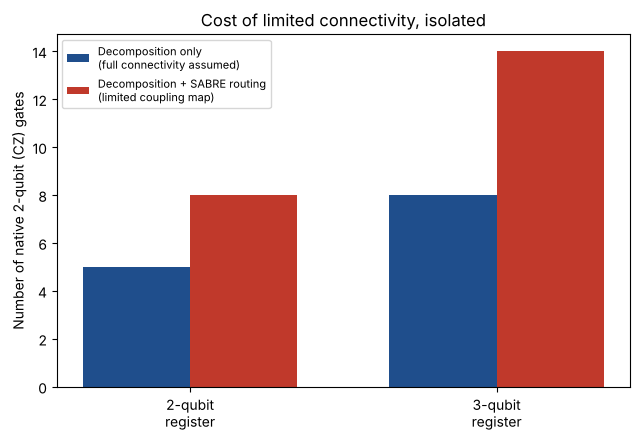

In [6]:
fig_data = []
for n in (2, 3):
    orig_cz = 0  # original circuit has 'cx'/'cry', not yet in native gates -- not directly comparable
    decomp_cz = decomposition_only[n].count_ops().get('cz', 0)
    full_cz = full_transpilation[n].count_ops().get('cz', 0)
    fig_data.append((n, decomp_cz, full_cz))

import matplotlib.pyplot as plt

labels = [f"{n}-qubit\nregister" for n, _, _ in fig_data]
decomp_vals = [d for _, d, _ in fig_data]
full_vals = [f for _, _, f in fig_data]

x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(x - width/2, decomp_vals, width, label='Decomposition only\n(full connectivity assumed)', color='#1f4e8c')
ax.bar(x + width/2, full_vals, width, label='Decomposition + SABRE routing\n(limited coupling map)', color='#c0392b')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Number of native 2-qubit (CZ) gates')
ax.set_title('Cost of limited connectivity, isolated')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('results/figures/stage05_transpilation_cost_breakdown.png', dpi=150)
plt.show()

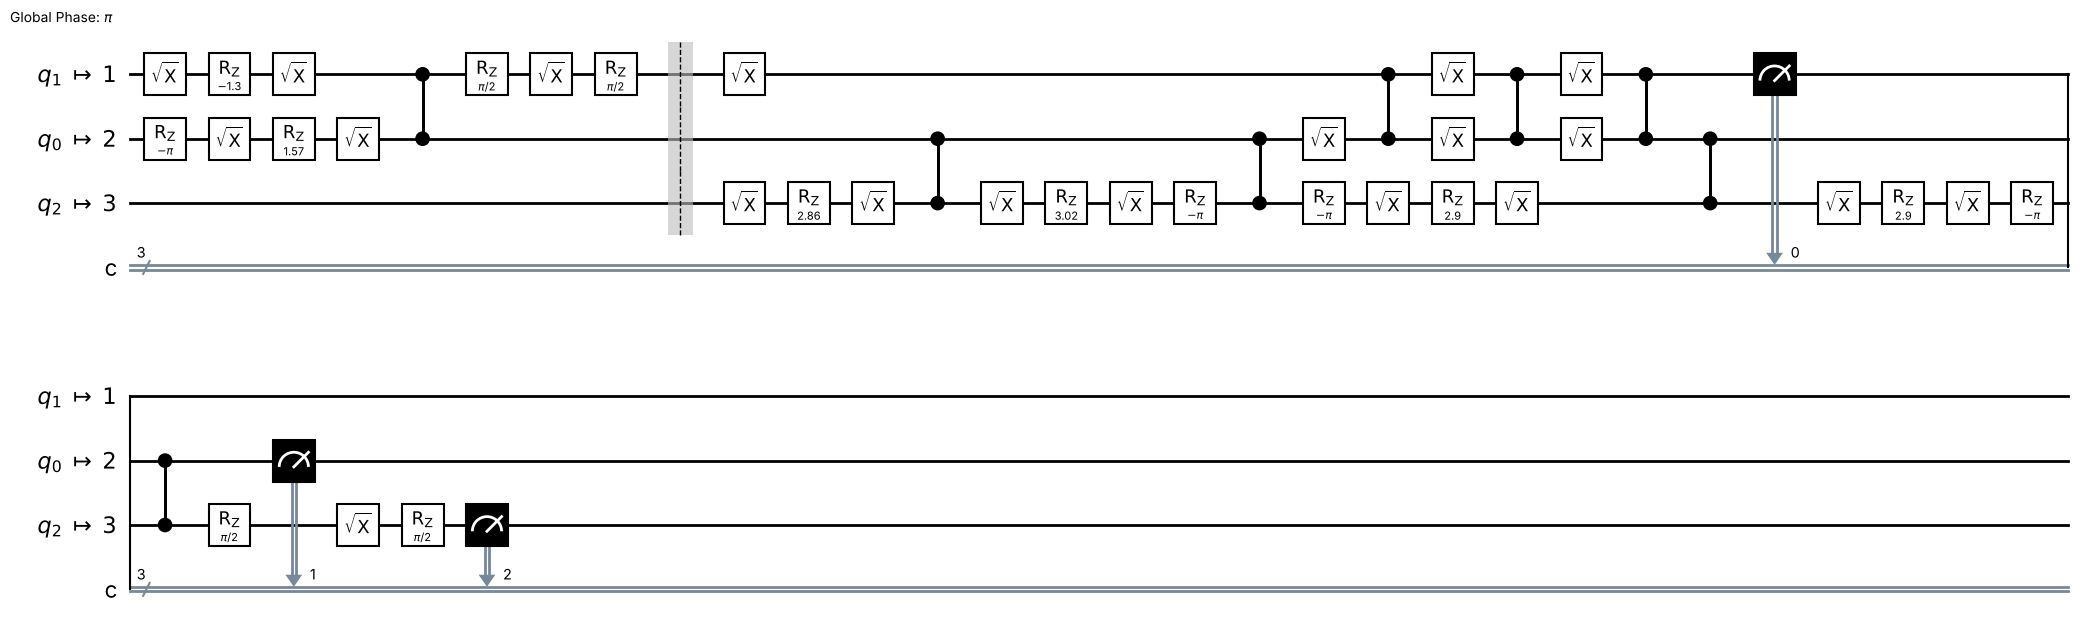

In [7]:
fig = full_transpilation[2].draw('mpl', style={'name': 'bw'}, fold=30)
fig.savefig('results/figures/stage05_circuit_2q_transpiled.png', dpi=150, bbox_inches='tight')
fig

In [8]:
for level in (0, 1, 2, 3):
    tqc = transpile(circuits[2], coupling_map=coupling_maps[2], basis_gates=NATIVE_GATES,
                     layout_method='sabre', routing_method='sabre',
                     optimization_level=level, seed_transpiler=7)
    print(f"optimization_level={level}: depth={tqc.depth():>3}, "
          f"gates={dict(tqc.count_ops())}")

optimization_level=0: depth= 66, gates={'rz': 41, 'sx': 30, 'cz': 8, 'measure': 3, 'barrier': 1}
optimization_level=1: depth= 33, gates={'sx': 20, 'rz': 14, 'cz': 8, 'measure': 3, 'barrier': 1}
optimization_level=2: depth= 31, gates={'sx': 18, 'rz': 15, 'cz': 8, 'x': 5, 'measure': 3, 'barrier': 1}
optimization_level=3: depth= 31, gates={'sx': 18, 'rz': 15, 'cz': 8, 'x': 3, 'measure': 3, 'barrier': 1}


In [9]:
import qiskit.qpy as qpy

with open("results/transpiled_circuits.qpy", "wb") as f:
    qpy.dump([full_transpilation[2], full_transpilation[3]], f)

transpilation_metadata = {}
for n in (2, 3):
    orig = circuits[n]
    tqc = full_transpilation[n]
    transpilation_metadata[f"{n}_qubit"] = {
        "original_depth": orig.depth(),
        "original_gate_counts": dict(orig.count_ops()),
        "transpiled_depth": tqc.depth(),
        "transpiled_gate_counts": dict(tqc.count_ops()),
        "coupling_map_edges": list(coupling_maps[n].get_edges()),
        "native_gates": NATIVE_GATES,
    }

with open("results/stage05_transpilation_results.json", "w") as f:
    json.dump(transpilation_metadata, f, indent=2)

print("Saved -> results/transpiled_circuits.qpy")
print("Saved -> results/stage05_transpilation_results.json")
print(json.dumps(transpilation_metadata, indent=2))

Saved -> results/transpiled_circuits.qpy
Saved -> results/stage05_transpilation_results.json
{
  "2_qubit": {
    "original_depth": 6,
    "original_gate_counts": {
      "ry": 3,
      "measure": 3,
      "cry": 2,
      "cx": 1,
      "barrier": 1
    },
    "transpiled_depth": 33,
    "transpiled_gate_counts": {
      "sx": 20,
      "rz": 14,
      "cz": 8,
      "measure": 3,
      "barrier": 1
    },
    "coupling_map_edges": [
      [
        0,
        1
      ],
      [
        1,
        2
      ],
      [
        2,
        3
      ]
    ],
    "native_gates": [
      "rz",
      "sx",
      "x",
      "cz"
    ]
  },
  "3_qubit": {
    "original_depth": 8,
    "original_gate_counts": {
      "ry": 4,
      "measure": 4,
      "cry": 3,
      "cx": 2,
      "barrier": 1
    },
    "transpiled_depth": 56,
    "transpiled_gate_counts": {
      "sx": 33,
      "rz": 23,
      "cz": 14,
      "measure": 4,
      "barrier": 1
    },
    "coupling_map_edges": [
      [
        0,
